In [2]:
# Regresión con el conjunto de datos `beisbol.csv`

## Objetivo

#El objetivo de este ejercicio es desarrollar un modelo de regresión capaz de predecir la cantidad de carreras (`runs`) de un equipo de béisbol a partir de la cantidad de bateos (`bateos`).

#Durante el desarrollo se realizará:

#1. Exploración y preparación de los datos.
#2. Análisis del comportamiento de las variables.
#3. Entrenamiento de un modelo de Regresión Lineal.
#4. Evaluación mediante métricas.
#5. Optimización mediante búsqueda de hiperparámetros.
#6. Comparación con modelos regularizados.
#7. Selección del mejor modelo.
#8. Visualización de resultados.
#9. Guardado del modelo final.


In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import joblib

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


In [4]:
# Ruta del conjunto de datos
ruta = "/Users/x/OneDrive/Escritorio/universidad/9no/fili/analisis-supervisado-no-supervisado/datasets/beisbol.csv"

# Cargar dataset
df = pd.read_csv(ruta)

print("Dataset cargado correctamente.")
print(f"Filas: {df.shape[0]}")
print(f"Columnas: {df.shape[1]}")

Dataset cargado correctamente.
Filas: 30
Columnas: 4


In [5]:
df.head()

,Unnamed: 0,equipos,bateos,runs
0,0,Texas,5659,855
1,1,Boston,5710,875
2,2,Detroit,5563,787
3,3,Kansas,5672,730
4,4,St.,5532,762


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Unnamed: 0  30 non-null     int64
 1   equipos     30 non-null     str  
 2   bateos      30 non-null     int64
 3   runs        30 non-null     int64
dtypes: int64(3), str(1)
memory usage: 1.1 KB


In [8]:
df.describe()

,Unnamed: 0,bateos,runs
count,30.000000,30.000000,30.000000
mean,14.500000,5523.500000,693.600000
std,8.803408,79.873067,82.479088
min,0.000000,5417.000000,556.000000
25%,7.250000,5448.250000,629.000000
50%,14.500000,5515.500000,705.500000
75%,21.750000,5575.000000,734.000000
max,29.000000,5710.000000,875.000000


In [9]:
print("Valores nulos:")
print(df.isnull().sum())

Valores nulos:
Unnamed: 0    0
equipos       0
bateos        0
runs          0
dtype: int64


In [10]:
# Variable independiente
X = df[["bateos"]]

# Variable dependiente
y = df["runs"]

print("Variable independiente (X):", X.columns.tolist())
print("Variable dependiente (y):", y.name)

Variable independiente (X): ['bateos']
Variable dependiente (y): runs


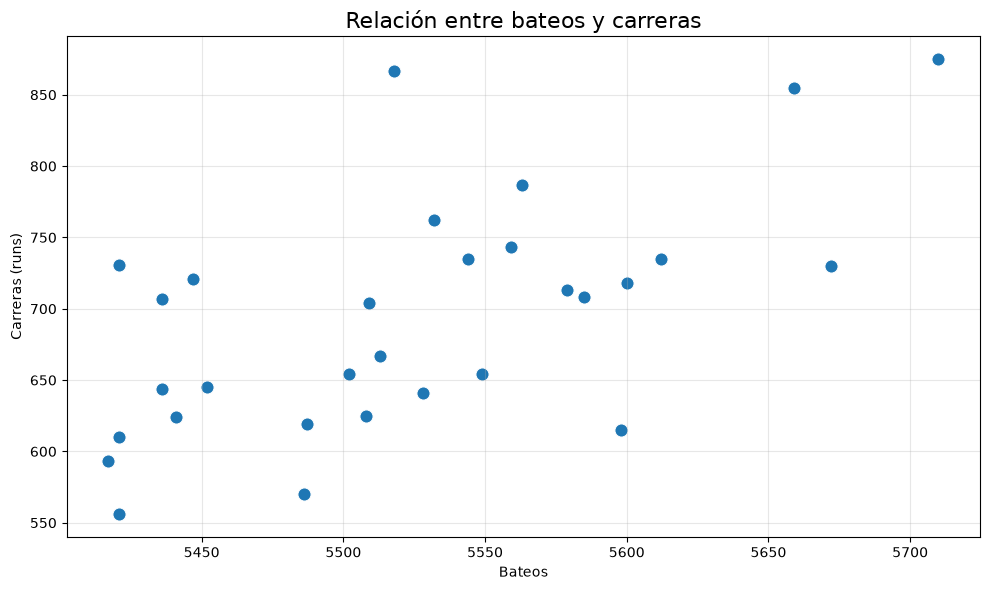

In [12]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="bateos",
    y="runs",
    s=90
)

plt.title("Relación entre bateos y carreras", fontsize=16)
plt.xlabel("Bateos")
plt.ylabel("Carreras (runs)")
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig("/Users/x/OneDrive/Escritorio/universidad/9no/fili/analisis-supervisado-no-supervisado/figuras/beisbol_dispersion.png", dpi=300, bbox_inches="tight")

plt.show()

In [13]:
df.shape
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Unnamed: 0  30 non-null     int64
 1   equipos     30 non-null     str  
 2   bateos      30 non-null     int64
 3   runs        30 non-null     int64
dtypes: int64(3), str(1)
memory usage: 1.1 KB


Unnamed: 0    0
equipos       0
bateos        0
runs          0
dtype: int64

In [14]:
# Eliminar la columna de índice generada por el CSV
df = df.drop(columns=["Unnamed: 0"])

print("Columnas después de la limpieza:")
print(df.columns.tolist())

df.head()

Columnas después de la limpieza:
['equipos', 'bateos', 'runs']


,equipos,bateos,runs
0,Texas,5659,855
1,Boston,5710,875
2,Detroit,5563,787
3,Kansas,5672,730
4,St.,5532,762


In [15]:
# Variable independiente
X = df[["bateos"]]

# Variable dependiente
y = df["runs"]

print("Forma de X:", X.shape)
print("Forma de y:", y.shape)
print("\nPrimeros valores de X:")
print(X.head())

print("\nPrimeros valores de y:")
print(y.head())

Forma de X: (30, 1)
Forma de y: (30,)

Primeros valores de X:
   bateos
0    5659
1    5710
2    5563
3    5672
4    5532

Primeros valores de y:
0    855
1    875
2    787
3    730
4    762
Name: runs, dtype: int64


In [16]:
# Dividir los datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Datos de entrenamiento:", X_train.shape[0])
print("Datos de prueba:", X_test.shape[0])

Datos de entrenamiento: 24
Datos de prueba: 6


In [17]:
# Crear el modelo de Regresión Lineal
modelo_lineal = LinearRegression()

# Entrenar el modelo
modelo_lineal.fit(X_train, y_train)

print("Modelo de Regresión Lineal entrenado correctamente.")

Modelo de Regresión Lineal entrenado correctamente.


In [18]:
print("Pendiente (coeficiente):", modelo_lineal.coef_[0])
print("Intercepto:", modelo_lineal.intercept_)

Pendiente (coeficiente): 0.6668508650552262
Intercepto: -2981.517212576021


In [19]:
# Generar predicciones con los datos de prueba
y_pred = modelo_lineal.predict(X_test)

print("Predicciones realizadas correctamente.")
print(y_pred)

Predicciones realizadas correctamente.
[676.82663312 738.84376357 654.15370371 692.16420301 715.50398329
 751.51393   ]


In [20]:
# Crear una tabla comparativa
comparacion = pd.DataFrame({
    "Valor real": y_test.values,
    "Valor predicho": y_pred
})

comparacion

,Valor real,Valor predicho
0,570,676.826633
1,713,738.843764
2,645,654.153704
3,704,692.164203
4,735,715.503983
5,615,751.513930


In [21]:
# Calcular métricas de evaluación
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²: {r2:.4f}")

MAE: 51.6116
RMSE: 72.2494
R²: -0.5175


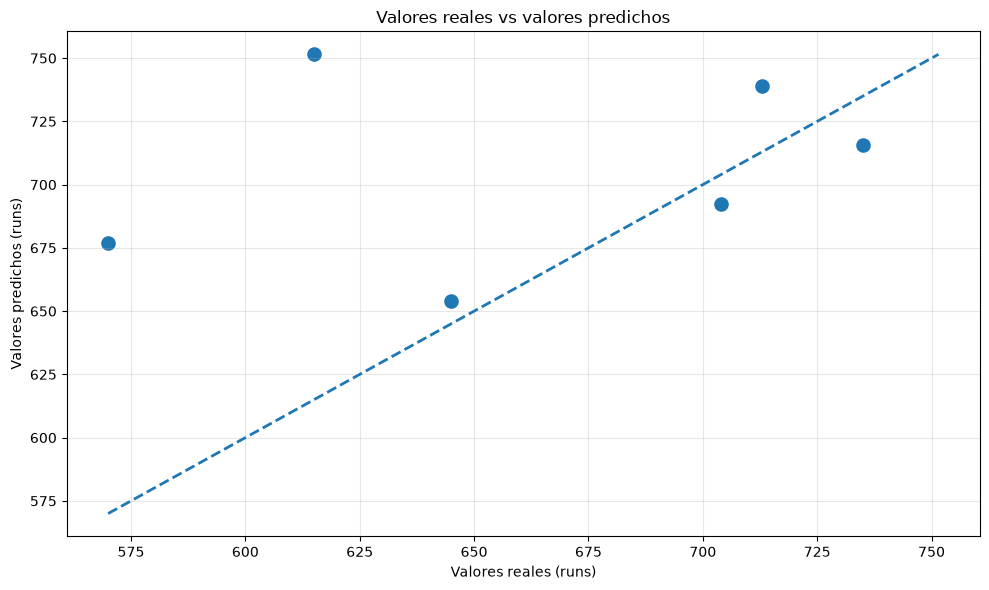

In [22]:
plt.figure(figsize=(10, 6))

plt.scatter(y_test, y_pred, s=90)

# Línea ideal: predicción = valor real
limite_min = min(y_test.min(), y_pred.min())
limite_max = max(y_test.max(), y_pred.max())

plt.plot(
    [limite_min, limite_max],
    [limite_min, limite_max],
    linestyle="--",
    linewidth=2
)

plt.xlabel("Valores reales (runs)")
plt.ylabel("Valores predichos (runs)")
plt.title("Valores reales vs valores predichos")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(
    "/Users/x/OneDrive/Escritorio/universidad/9no/fili/analisis-supervisado-no-supervisado/figuras/beisbol_real_predicho.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

C:\Users\x\OneDrive\Escritorio\universidad\9no\fili\filiberto\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


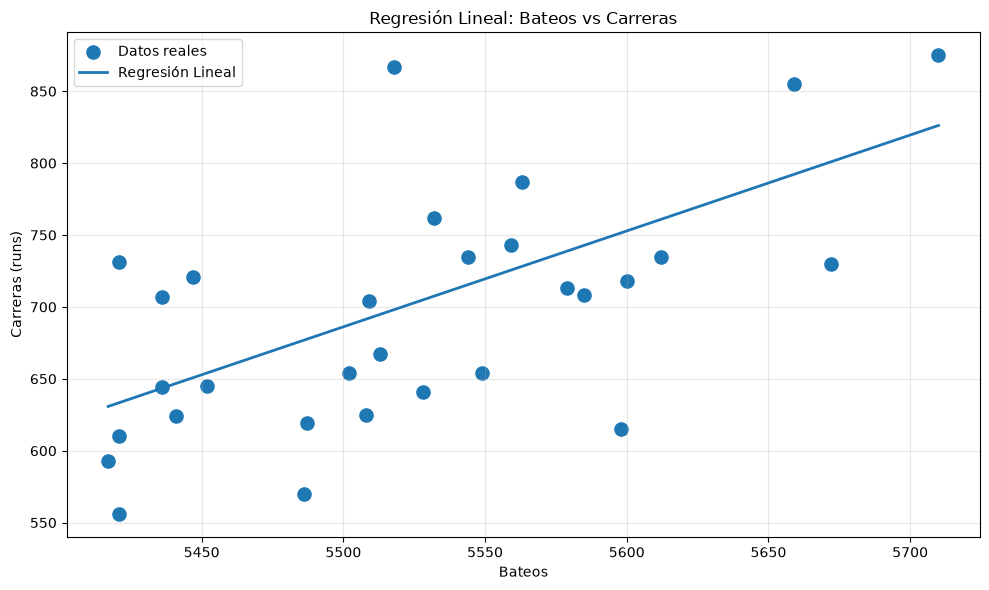

In [23]:
plt.figure(figsize=(10, 6))

# Datos originales
plt.scatter(
    df["bateos"],
    df["runs"],
    s=90,
    label="Datos reales"
)

# Generar valores para dibujar la recta
x_linea = np.linspace(
    df["bateos"].min(),
    df["bateos"].max(),
    100
).reshape(-1, 1)

y_linea = modelo_lineal.predict(x_linea)

# Dibujar la recta de regresión
plt.plot(
    x_linea,
    y_linea,
    linewidth=2,
    label="Regresión Lineal"
)

plt.xlabel("Bateos")
plt.ylabel("Carreras (runs)")
plt.title("Regresión Lineal: Bateos vs Carreras")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [24]:
# Validación cruzada con 5 particiones
scores = cross_val_score(
    modelo_lineal,
    X,
    y,
    cv=5,
    scoring="r2"
)

print("Resultados de R² por partición:")
print(scores)

print(f"\nR² promedio: {scores.mean():.4f}")
print(f"Desviación estándar: {scores.std():.4f}")

Resultados de R² por partición:
[-1.06322413 -0.55530097 -0.09209403 -0.02235244 -1.15050052]

R² promedio: -0.5767
Desviación estándar: 0.4709


In [25]:
# Modelos regularizados
ridge = Ridge()
lasso = Lasso()

# Valores de alpha que vamos a probar
parametros = {
    "alpha": [0.01, 0.1, 1, 10, 100, 1000]
}

# Búsqueda de hiperparámetros para Ridge
grid_ridge = GridSearchCV(
    ridge,
    parametros,
    cv=5,
    scoring="r2"
)

grid_ridge.fit(X_train, y_train)

print("Mejor alpha para Ridge:", grid_ridge.best_params_)
print("Mejor R² de Ridge:", grid_ridge.best_score_)

Mejor alpha para Ridge: {'alpha': 1000}
Mejor R² de Ridge: 0.20864140241086218


In [26]:
# Búsqueda de hiperparámetros para Lasso
grid_lasso = GridSearchCV(
    lasso,
    parametros,
    cv=5,
    scoring="r2"
)

grid_lasso.fit(X_train, y_train)

print("Mejor alpha para Lasso:", grid_lasso.best_params_)
print("Mejor R² de Lasso:", grid_lasso.best_score_)

Mejor alpha para Lasso: {'alpha': 100}
Mejor R² de Lasso: 0.20954639306862433


In [27]:
# Modelos optimizados
modelo_ridge = grid_ridge.best_estimator_
modelo_lasso = grid_lasso.best_estimator_

# Predicciones
pred_lineal = modelo_lineal.predict(X_test)
pred_ridge = modelo_ridge.predict(X_test)
pred_lasso = modelo_lasso.predict(X_test)

# Función para calcular métricas
def evaluar_modelo(nombre, y_real, y_pred):
    mae = mean_absolute_error(y_real, y_pred)
    rmse = np.sqrt(mean_squared_error(y_real, y_pred))
    r2 = r2_score(y_real, y_pred)

    return {
        "Modelo": nombre,
        "MAE": mae,
        "RMSE": rmse,
        "R²": r2
    }

resultados = pd.DataFrame([
    evaluar_modelo("Regresión Lineal", y_test, pred_lineal),
    evaluar_modelo("Ridge", y_test, pred_ridge),
    evaluar_modelo("Lasso", y_test, pred_lasso)
])

resultados

,Modelo,MAE,RMSE,R²
0,Regresión Lineal,51.611641,72.249399,-0.517484
1,Ridge,51.600376,72.186440,-0.514840
2,Lasso,51.570861,72.023878,-0.508025


In [28]:
# Seleccionar el modelo con mayor R²
mejor_modelo_nombre = resultados.loc[
    resultados["R²"].idxmax(),
    "Modelo"
]

print("Mejor modelo:", mejor_modelo_nombre)

Mejor modelo: Lasso


In [29]:
# Obtener el objeto del mejor modelo
modelos = {
    "Regresión Lineal": modelo_lineal,
    "Ridge": modelo_ridge,
    "Lasso": modelo_lasso
}

mejor_modelo = modelos[mejor_modelo_nombre]

# Guardar modelo
os.makedirs("../models/regression", exist_ok=True)

joblib.dump(
    mejor_modelo,
    "../models/regression/mejor_modelo_beisbol.pkl"
)

print("Modelo guardado correctamente.")

Modelo guardado correctamente.


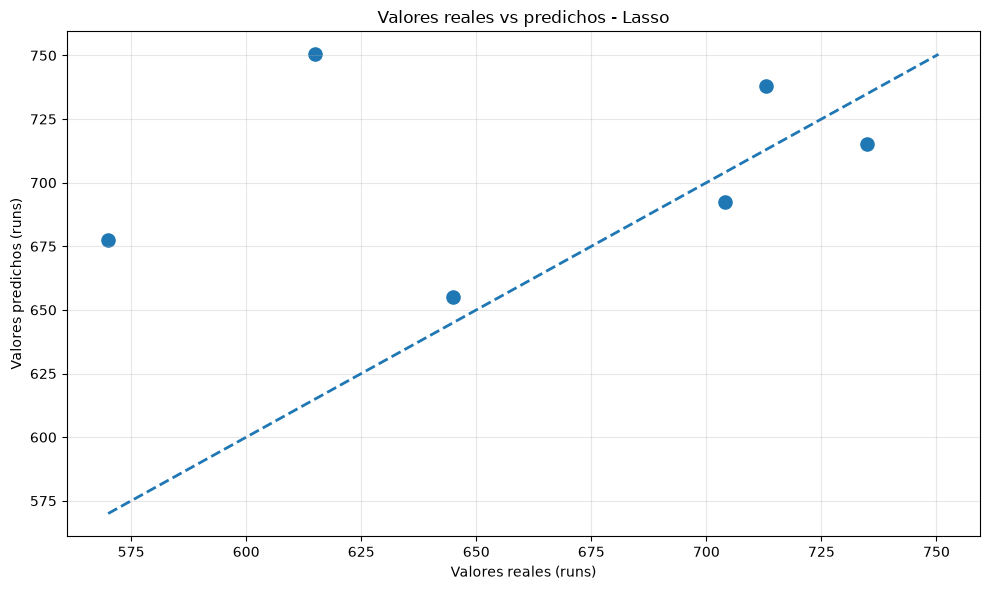

In [30]:
# Predicciones del modelo final
y_pred_final = mejor_modelo.predict(X_test)

plt.figure(figsize=(10, 6))

plt.scatter(
    y_test,
    y_pred_final,
    s=90
)

limite_min = min(y_test.min(), y_pred_final.min())
limite_max = max(y_test.max(), y_pred_final.max())

plt.plot(
    [limite_min, limite_max],
    [limite_min, limite_max],
    linestyle="--",
    linewidth=2
)

plt.xlabel("Valores reales (runs)")
plt.ylabel("Valores predichos (runs)")
plt.title(f"Valores reales vs predichos - {mejor_modelo_nombre}")
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "../figuras/beisbol_real_predicho.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [31]:
resultados.to_csv(
    "../models/regression/resultados_modelos.csv",
    index=False
)

print("Resultados guardados correctamente.")

Resultados guardados correctamente.


In [32]:
mejor_modelo_nombre = resultados.loc[
    resultados["R²"].idxmax(),
    "Modelo"
]

print("Mejor modelo:", mejor_modelo_nombre)

Mejor modelo: Lasso


In [33]:
modelos = {
    "Regresión Lineal": modelo_lineal,
    "Ridge": modelo_ridge,
    "Lasso": modelo_lasso
}

mejor_modelo = modelos[mejor_modelo_nombre]

os.makedirs("../models/regression", exist_ok=True)

joblib.dump(
    mejor_modelo,
    "../models/regression/mejor_modelo_beisbol.pkl"
)

print("Modelo guardado correctamente.")

Modelo guardado correctamente.
